<a href="https://colab.research.google.com/github/mariabandeira/Telecom-X-Parte-2-Brasil/blob/main/TelecomX2_br.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

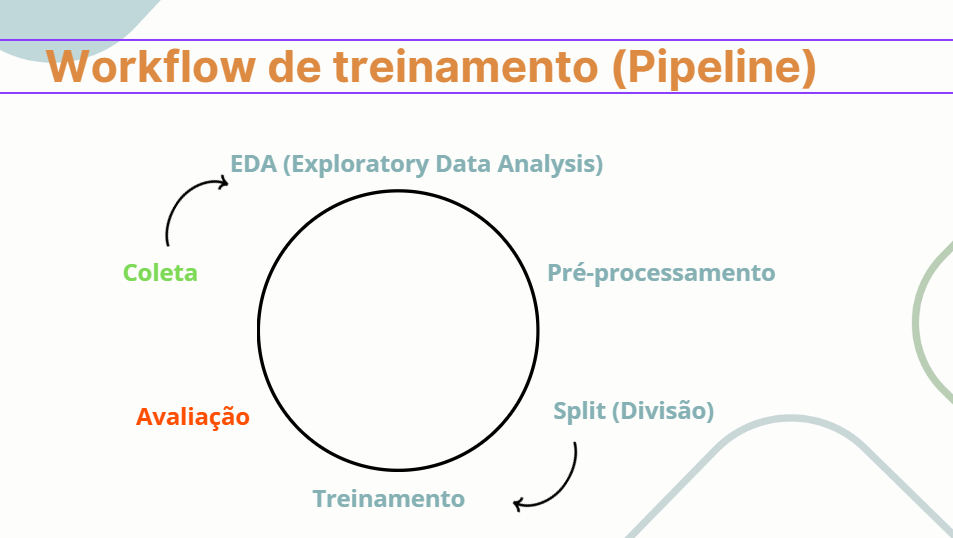

##📌 Extração (coleta)

In [1]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [3]:
df = pd.read_csv('/content/dados_tratados.csv')
df.head()

,id,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,0002-ORFBO,não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.6,593.30,2.186667
1,0003-MKNFE,não,Masculino,0,Não,Não,9,Sim,Sim,DSL,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.9,542.40,1.996667
2,0004-TLHLJ,sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.9,280.85,2.463333
3,0011-IGKFF,sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.0,1237.85,3.266667
4,0013-EXCHZ,sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.9,267.40,2.796667


In [4]:
df.columns

Index(['id', 'Churn', 'genero', 'tem +60', 'possui_parceiro',
       'possui_dependentes', 'tempo_contrato', 'servico_telefone',
       'multiplas_linhas', 'tipo_internet', 'seguranca_online',
       'backup_online', 'protecao_dispositivo', 'suporte_tecnico',
       'streaming_tv', 'streaming_filmes', 'tipo_contrato', 'fatura_digital',
       'metodo_pagamento', 'valor_mensal', 'total_cobrado', 'contas_diarias'],
      dtype='object')

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 22 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    7032 non-null   object 
 1   Churn                 7032 non-null   object 
 2   genero                7032 non-null   object 
 3   tem +60               7032 non-null   int64  
 4   possui_parceiro       7032 non-null   object 
 5   possui_dependentes    7032 non-null   object 
 6   tempo_contrato        7032 non-null   int64  
 7   servico_telefone      7032 non-null   object 
 8   multiplas_linhas      7032 non-null   object 
 9   tipo_internet         7032 non-null   object 
 10  seguranca_online      7032 non-null   object 
 11  backup_online         7032 non-null   object 
 12  protecao_dispositivo  7032 non-null   object 
 13  suporte_tecnico       7032 non-null   object 
 14  streaming_tv          7032 non-null   object 
 15  streaming_filmes     

##🛠️ Pre processamento

✔️ Remover colunas irrelevantes

In [6]:
df = df.drop(columns=['id'])

In [7]:
df

,Churn,genero,tem +60,possui_parceiro,possui_dependentes,tempo_contrato,servico_telefone,multiplas_linhas,tipo_internet,seguranca_online,...,protecao_dispositivo,suporte_tecnico,streaming_tv,streaming_filmes,tipo_contrato,fatura_digital,metodo_pagamento,valor_mensal,total_cobrado,contas_diarias
0,não,Feminino,0,Sim,Sim,9,Sim,Não,DSL,Não,...,Não,Sim,Sim,Não,Anual,Sim,Cheque enviado,65.60,593.30,2.186667
1,não,Masculino,0,Não,Não,9,Sim,Sim,DSL,Não,...,Não,Não,Não,Sim,Mensal,Não,Cheque enviado,59.90,542.40,1.996667
2,sim,Masculino,0,Não,Não,4,Sim,Não,Fiber optic,Não,...,Sim,Não,Não,Não,Mensal,Sim,Cheque eletrônico,73.90,280.85,2.463333
3,sim,Masculino,1,Sim,Não,13,Sim,Não,Fiber optic,Não,...,Sim,Não,Sim,Sim,Mensal,Sim,Cheque eletrônico,98.00,1237.85,3.266667
4,sim,Feminino,1,Sim,Não,3,Sim,Não,Fiber optic,Não,...,Não,Sim,Sim,Não,Mensal,Sim,Cheque enviado,83.90,267.40,2.796667
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7027,não,Feminino,0,Não,Não,13,Sim,Não,DSL,Sim,...,Não,Sim,Não,Não,Anual,Não,Cheque enviado,55.15,742.90,1.838333
7028,sim,Masculino,0,Sim,Não,22,Sim,Sim,Fiber optic,Não,...,Não,Não,Não,Sim,Mensal,Sim,Cheque eletrônico,85.10,1873.70,2.836667
7029,não,Masculino,0,Não,Não,2,Sim,Não,DSL,Não,...,Não,Não,Não,Não,Mensal,Sim,Cheque enviado,50.30,92.75,1.676667
7030,não,Masculino,0,Sim,Sim,67,Sim,Não,DSL,Sim,...,Sim,Sim,Não,Sim,Bienal,Não,Cheque enviado,67.85,4627.65,2.261667


In [9]:
for col in df.columns:
  print(f'{col}: {df[col].unique()}')
  if df[col].nunique() < 50:
    print(df[col].unique())
    print('-' * 100)

Churn: ['não' 'sim']
['não' 'sim']
----------------------------------------------------------------------------------------------------
genero: ['Feminino' 'Masculino']
['Feminino' 'Masculino']
----------------------------------------------------------------------------------------------------
tem +60: [0 1]
[0 1]
----------------------------------------------------------------------------------------------------
possui_parceiro: ['Sim' 'Não']
['Sim' 'Não']
----------------------------------------------------------------------------------------------------
possui_dependentes: ['Sim' 'Não']
['Sim' 'Não']
----------------------------------------------------------------------------------------------------
tempo_contrato: [ 9  4 13  3 71 63  7 65 54 72  5 56 34  1 45 50 23 55 26 69 37 49 66 67
 20 43 59 12 27  2 25 29 14 35 64 39 40 11  6 30 70 57 58 16 32 33 10 21
 61 15 44 22 24 19 47 62 46 52  8 60 48 28 41 53 68 31 36 17 18 51 38 42]
servico_telefone: ['Sim' 'Não']
['Sim' 'Não']
------

✔️ Agrupamentode **No** y **No service**

In [10]:
cols_to_fix = [
    'seguranca_online', 'backup_online', 'protecao_dispositivo',
    'suporte_tecnico', 'streaming_tv', 'streaming_filmes'
]

for col in cols_to_fix:
    df[col] = df[col].replace('Sem serviço de internet', 'No')

✔️ Verificação novamente de valore nulos

In [11]:
df.isnull().sum()

,0
Churn,0
genero,0
tem +60,0
possui_parceiro,0
possui_dependentes,0
tempo_contrato,0
servico_telefone,0
multiplas_linhas,0
tipo_internet,0
seguranca_online,0


## 📊 EDA

✔️ Correlação entre variaveis numericas

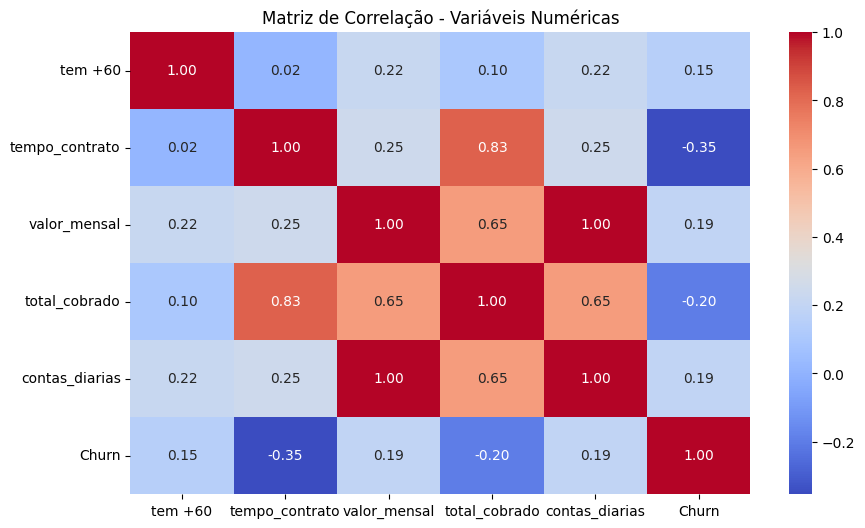

In [12]:
# Selecionar apenas variáveis numéricas
df_numeric = df.select_dtypes(include=["int64", "float64"])

# Converter Churn para numérico
df_numeric["Churn"] = df["Churn"].map({"sim": 1, "não": 0})


# Calcular matriz de correlação
corr_matrix = df_numeric.corr()

# Visualizar heatmap
plt.figure(figsize=(10,6))
sns.heatmap(corr_matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Matriz de Correlação - Variáveis Numéricas")
plt.show()


In [13]:
df = df.drop(columns=['total_cobrado', 'contas_diarias'])

2️⃣ Análise de churn por categoria (variáveis categóricas)

🔹 Selecionar variáveis categóricas

In [14]:
categorical_cols = df.select_dtypes(include=["object"]).columns
categorical_cols = categorical_cols.drop("Churn")

🔹 Tabela de proporção de churn por categoria

In [15]:
for col in categorical_cols:
    print(f"\n📌 Análise da variável: {col}")
    #Ele cria uma tabela de porcentagem de churn dentro de cada categoria de uma variável.
    display(pd.crosstab(df[col], df["Churn"], normalize="index") * 100)



📌 Análise da variável: genero


Churn,não,sim
genero,,
Feminino,73.040482,26.959518
Masculino,73.795435,26.204565



📌 Análise da variável: possui_parceiro


Churn,não,sim
possui_parceiro,,
Não,67.023908,32.976092
Sim,80.282935,19.717065



📌 Análise da variável: possui_dependentes


...

Churn,não,sim
tipo_contrato,,
Anual,88.722826,11.277174
Bienal,97.151335,2.848665
Mensal,57.290323,42.709677



📌 Análise da variável: fatura_digital


Churn,não,sim
fatura_digital,,
Não,83.624302,16.375698
Sim,66.410749,33.589251



📌 Análise da variável: metodo_pagamento


Churn,não,sim
metodo_pagamento,,
Cartão de crédito (automático),84.746877,15.253123
Cheque eletrônico,54.714588,45.285412
Cheque enviado,80.798005,19.201995
Transferência bancária (automática),83.268482,16.731518


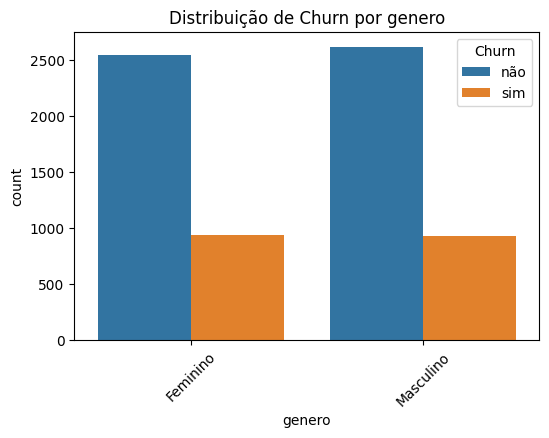

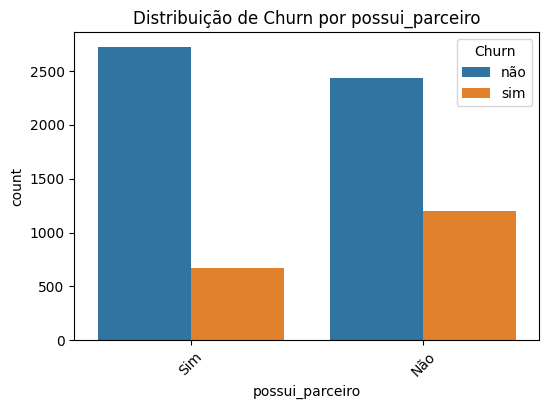

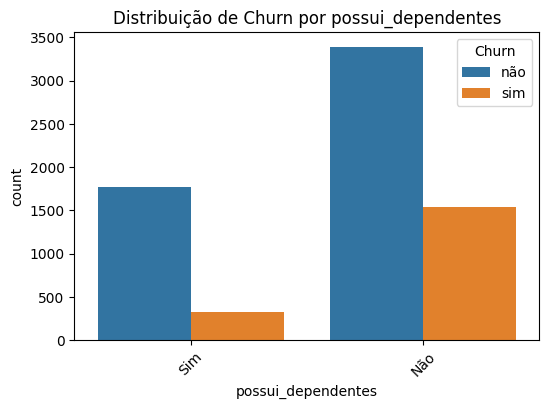

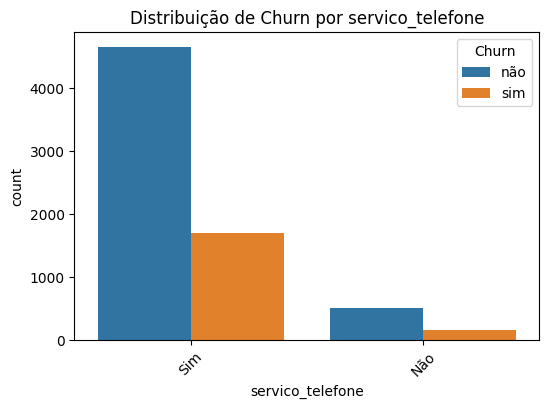

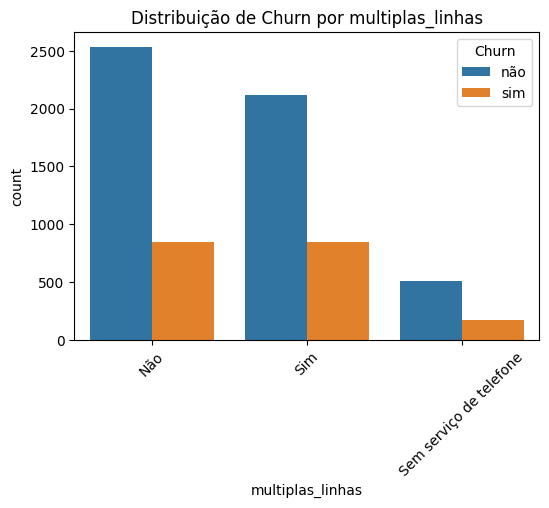

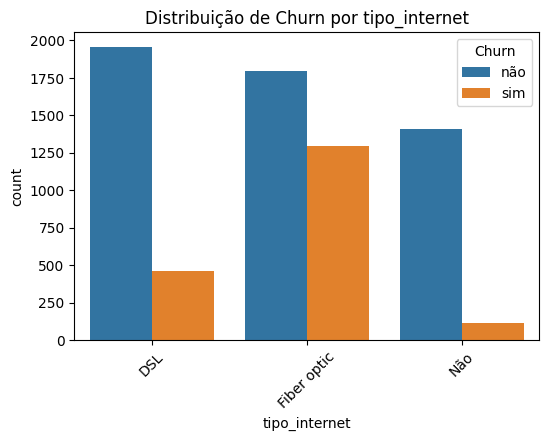

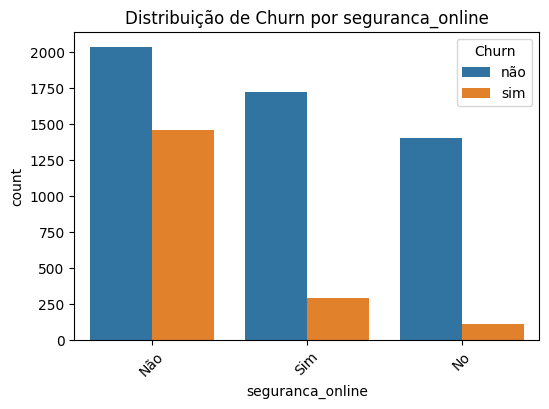

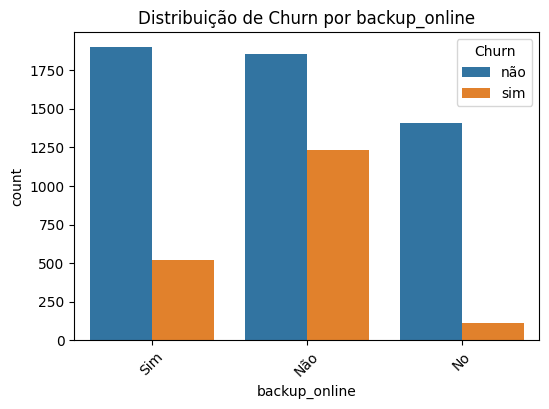

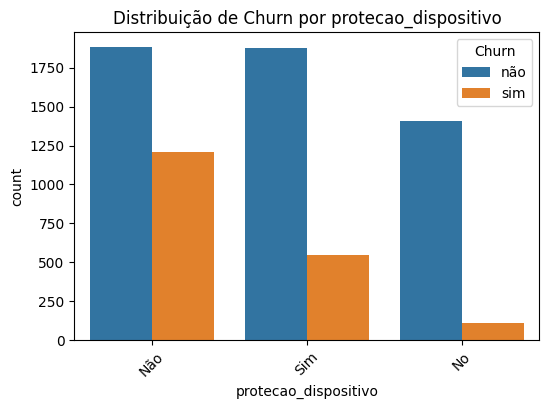

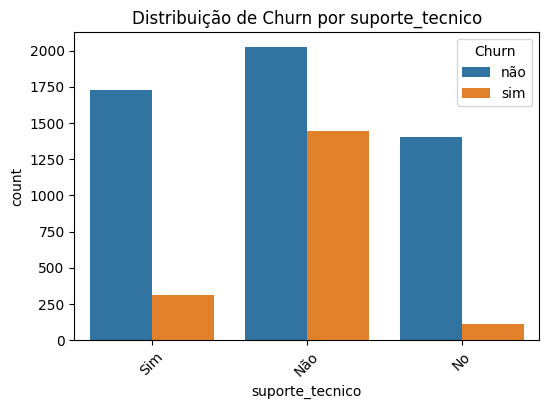

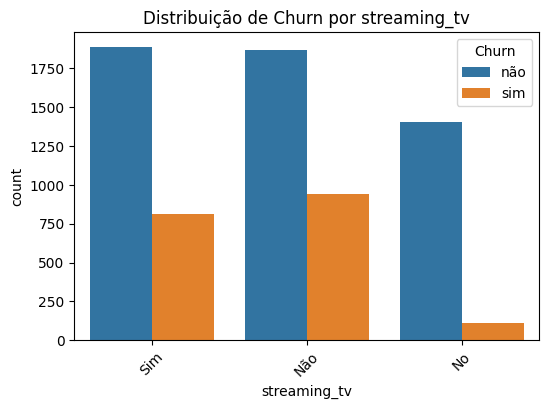

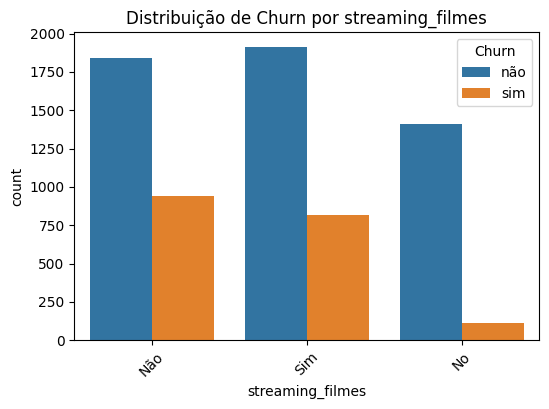

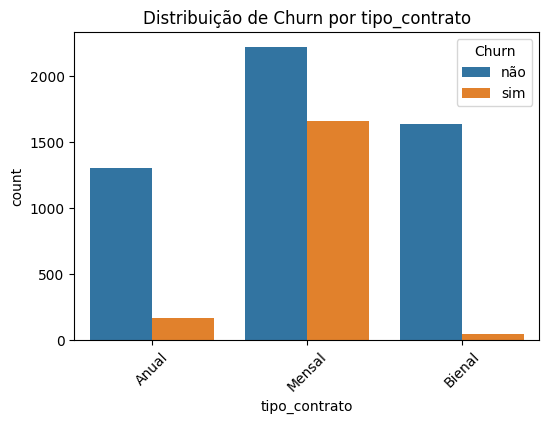

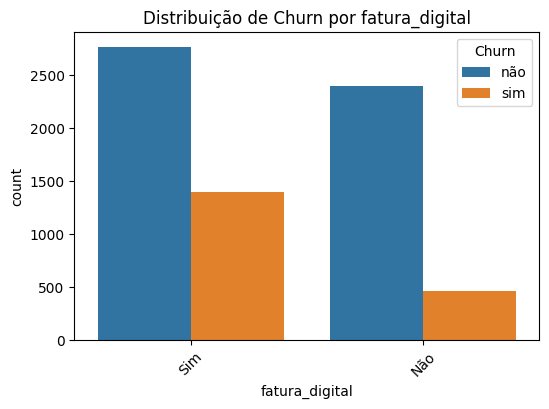

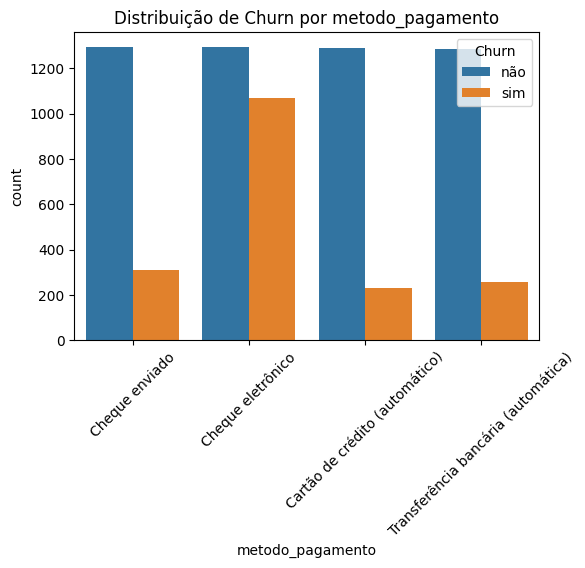

In [16]:
for col in categorical_cols:
    plt.figure(figsize=(6,4))
    sns.countplot(data=df, x=col, hue="Churn")
    plt.title(f"Distribuição de Churn por {col}")
    plt.xticks(rotation=45)
    plt.show()

In [17]:
from sklearn.preprocessing import LabelEncoder
from sklearn.feature_selection import chi2

# Criar cópia
df_rank = df.copy()

# Converter Churn para binário
df_rank["Churn"] = df_rank["Churn"].map({"sim": 1, "não": 0})

# Separar variáveis categóricas
categorical_cols = df_rank.select_dtypes(include=["object"]).columns

# Aplicar Label Encoding temporário (apenas para teste estatístico)
le = LabelEncoder()
for col in categorical_cols:
    df_rank[col] = le.fit_transform(df_rank[col])

# Separar X e y
X_cat = df_rank[categorical_cols]
y = df_rank["Churn"]

# Aplicar teste Qui-quadrado
chi_scores, p_values = chi2(X_cat, y)

# Criar DataFrame com ranking
chi_df = pd.DataFrame({
    "Variável": categorical_cols,
    "Chi2 Score": chi_scores,
    "p-value": p_values
})

# Ordenar por importância
chi_df = chi_df.sort_values(by="Chi2 Score", ascending=False)

chi_df


,Variável,Chi2 Score,p-value
12,tipo_contrato,392.706273,2.131687e-87
2,possui_dependentes,131.271509,2.159540e-30
13,fatura_digital,104.979224,1.234232e-24
10,streaming_tv,93.220049,4.679171e-22
11,streaming_filmes,91.256385,1.262121e-21
1,possui_parceiro,81.857769,1.462409e-19
14,metodo_pagamento,31.337803,2.168166e-08
8,protecao_dispositivo,24.151802,8.903284e-07
7,backup_online,18.541627,1.662338e-05
4,multiplas_linhas,9.735960,1.806976e-03


In [18]:
significant_vars = chi_df[chi_df["p-value"] < 0.05]
print("\n✅ Variables significativas (p < 0.05):")
display(significant_vars)


✅ Variables significativas (p < 0.05):


,Variável,Chi2 Score,p-value
12,tipo_contrato,392.706273,2.131687e-87
2,possui_dependentes,131.271509,2.159540e-30
13,fatura_digital,104.979224,1.234232e-24
10,streaming_tv,93.220049,4.679171e-22
11,streaming_filmes,91.256385,1.262121e-21
1,possui_parceiro,81.857769,1.462409e-19
14,metodo_pagamento,31.337803,2.168166e-08
8,protecao_dispositivo,24.151802,8.903284e-07
7,backup_online,18.541627,1.662338e-05
4,multiplas_linhas,9.735960,1.806976e-03


In [19]:
df = df.drop(columns=["genero", "servico_telefone"])

In [20]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7032 entries, 0 to 7031
Data columns (total 17 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   Churn                 7032 non-null   object 
 1   tem +60               7032 non-null   int64  
 2   possui_parceiro       7032 non-null   object 
 3   possui_dependentes    7032 non-null   object 
 4   tempo_contrato        7032 non-null   int64  
 5   multiplas_linhas      7032 non-null   object 
 6   tipo_internet         7032 non-null   object 
 7   seguranca_online      7032 non-null   object 
 8   backup_online         7032 non-null   object 
 9   protecao_dispositivo  7032 non-null   object 
 10  suporte_tecnico       7032 non-null   object 
 11  streaming_tv          7032 non-null   object 
 12  streaming_filmes      7032 non-null   object 
 13  tipo_contrato         7032 non-null   object 
 14  fatura_digital        7032 non-null   object 
 15  metodo_pagamento     

## 🎯 Split

1. Separação de X e Y

In [21]:
X = df.drop("Churn", axis=1)
y = df["Churn"]

2. Split

In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    stratify=y,
    random_state=42
)

3.One-Hot Encoding

In [23]:
# Aplicar One-Hot Encoding no treino
X_train = pd.get_dummies(X_train, drop_first=True)

# Aplicar no teste
X_test = pd.get_dummies(X_test, drop_first=True)

# Garantir que treino e teste tenham as mesmas colunas
X_train, X_test = X_train.align(X_test, join='left', axis=1, fill_value=0)

In [24]:
X_train.head()

,tem +60,tempo_contrato,valor_mensal,possui_parceiro_Sim,possui_dependentes_Sim,multiplas_linhas_Sem serviço de telefone,multiplas_linhas_Sim,tipo_internet_Fiber optic,tipo_internet_Não,seguranca_online_Não,...,streaming_tv_Não,streaming_tv_Sim,streaming_filmes_Não,streaming_filmes_Sim,tipo_contrato_Bienal,tipo_contrato_Mensal,fatura_digital_Sim,metodo_pagamento_Cheque eletrônico,metodo_pagamento_Cheque enviado,metodo_pagamento_Transferência bancária (automática)
1416,0,37,20.35,True,False,False,False,False,True,False,...,False,False,False,False,False,True,False,False,False,True
6993,0,68,99.55,True,True,False,False,True,False,False,...,False,True,False,True,True,False,True,True,False,False
3417,1,3,73.85,False,False,False,False,True,False,True,...,True,False,True,False,False,True,False,True,False,False
4559,0,9,68.95,True,False,False,False,False,False,False,...,False,True,True,False,False,True,True,False,True,False
3604,0,56,65.20,True,True,False,True,False,False,False,...,False,True,True,False,False,False,False,False,False,True


4. Verificar desbalaceamento

In [25]:
y_train.value_counts(normalize=True) * 100

,proportion
Churn,
não,73.422222
sim,26.577778


##Treinamento

Modelo 1 — Regressão Logística

In [26]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

log_model = LogisticRegression(max_iter=1000)
log_model.fit(X_train, y_train)

y_pred_log_normal = log_model.predict(X_test)

print("Regressão Logística")
print(classification_report(y_test, y_pred_log_normal))

Regressão Logística
              precision    recall  f1-score   support

         não       0.84      0.90      0.87      1033
         sim       0.65      0.52      0.58       374

    accuracy                           0.80      1407
   macro avg       0.74      0.71      0.72      1407
weighted avg       0.79      0.80      0.79      1407



Modelo 2 — Random Forest

In [27]:
from sklearn.ensemble import RandomForestClassifier

rf_model = RandomForestClassifier(random_state=42)
rf_model.fit(X_train, y_train)

y_pred_rf = rf_model.predict(X_test)

print("Random Forest")
print(classification_report(y_test, y_pred_rf))

Random Forest
              precision    recall  f1-score   support

         não       0.83      0.89      0.86      1033
         sim       0.62      0.49      0.55       374

    accuracy                           0.79      1407
   macro avg       0.73      0.69      0.70      1407
weighted avg       0.77      0.79      0.78      1407



In [28]:
from sklearn.linear_model import LogisticRegression

log_model = LogisticRegression(max_iter=1000, class_weight="balanced")
log_model.fit(X_train, y_train)

y_pred_log = log_model.predict(X_test)

print(classification_report(y_test, y_pred_log))

              precision    recall  f1-score   support

         não       0.91      0.73      0.81      1033
         sim       0.52      0.79      0.62       374

    accuracy                           0.75      1407
   macro avg       0.71      0.76      0.72      1407
weighted avg       0.80      0.75      0.76      1407



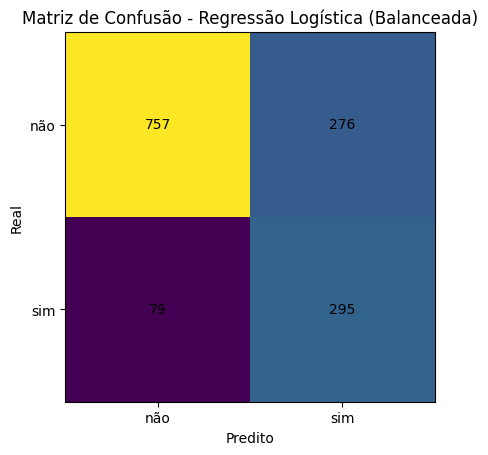

In [29]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_log)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusão - Regressão Logística (Balanceada)")
plt.xlabel("Predito")
plt.ylabel("Real")

# Colocar números dentro da matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["não", "sim"])
plt.yticks([0,1], ["não", "sim"])

plt.show()

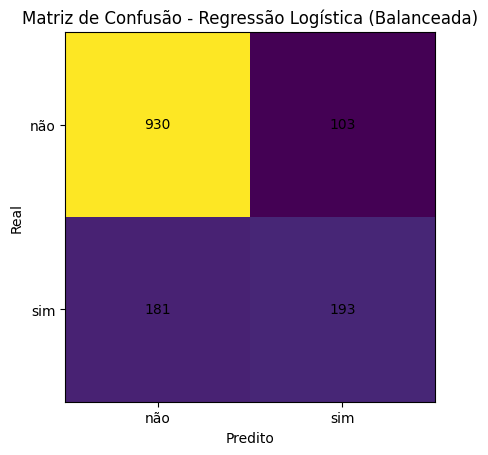

In [30]:
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import numpy as np

# Matriz de confusão
cm = confusion_matrix(y_test, y_pred_log_normal)

# Plot
plt.figure()
plt.imshow(cm)
plt.title("Matriz de Confusão - Regressão Logística (Balanceada)")
plt.xlabel("Predito")
plt.ylabel("Real")

# Colocar números dentro da matriz
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, cm[i, j], ha="center", va="center")

plt.xticks([0,1], ["não", "sim"])
plt.yticks([0,1], ["não", "sim"])

plt.show()

In [38]:
# Variáveis de maior importancia - Regressão Logística
importances = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": log_model.coef_[0]
})

importances = importances.sort_values(by="Importância", ascending=False)

importances[:10]

,Variável,Importância
7,tipo_internet_Fiber optic,1.112858
22,tipo_contrato_Mensal,0.731359
24,metodo_pagamento_Cheque eletrônico,0.442053
18,streaming_tv_Sim,0.357697
23,fatura_digital_Sim,0.342390
20,streaming_filmes_Sim,0.293900
15,suporte_tecnico_Não,0.289833
6,multiplas_linhas_Sim,0.279048
0,tem +60,0.266810
9,seguranca_online_Não,0.260809


In [39]:
# Variáveis de maior importancia - Random Forest
importances = pd.DataFrame({
    "Variável": X_train.columns,
    "Importância": rf_model.feature_importances_
})

importances = importances.sort_values(by="Importância", ascending=False)

importances[:10]

,Variável,Importância
2,valor_mensal,0.233077
1,tempo_contrato,0.228930
22,tipo_contrato_Mensal,0.069002
9,seguranca_online_Não,0.041392
24,metodo_pagamento_Cheque eletrônico,0.036775
7,tipo_internet_Fiber optic,0.033333
23,fatura_digital_Sim,0.029096
3,possui_parceiro_Sim,0.028517
15,suporte_tecnico_Não,0.026538
0,tem +60,0.025383


# Relatório Final

Após a análise, é possível observar que os principais fatores para o cancelamento são:

- tipo internet - Fiber optic
- tipo contrato - Mensal
- metodo pagamento - Cheque eletrônico
- streaming tv - Sim
- fatura digital - Sim
- streaming filmes - Sim
- suporte tecnico - Não
- multiplas linhas - Sim
- tem +60
- seguranca online - Não
- valor mensal
- tempo contrato
- possui parceiro - Sim

Visto isso, ações recomendadas são:

- Fazer campanhas de incentivo à fidelidade nos primeiros meses
- Fazer descontos especiais para planos anuais
- Sugerir revisão de preços

Além disso, os bons resultados apresentados pelos modelos permitem realizar uma análise individual dos clientes, possibilitando identificar aqueles que demandam maior atenção e, assim, adotar medidas preventivas de forma antecipada.


| Modelo               | Accuracy | Precision (Sim) | Recall (Sim) | F1-score (Sim) | Precision (Não) | Recall (Não) | F1-score (Não) |
|----------------------|----------|-----------------|--------------|---------------|-----------------|--------------|---------------|
| Regressão Logística  | 0.80     | 0.65            | 0.52         | 0.58          | 0.84            | 0.90         | 0.87          |
| Random Forest        | 0.79     | 0.62            | 0.49         | 0.55          | 0.83            | 0.89         | 0.86          |
| Regressão Logística Balanceada             | 0.75     | 0.52            | 0.79         | 0.62          | 0.91            | 0.73         | 0.81          |

---

## Conclusões

A avaliação realizada permitiu identificar e aprofundar em circunstâncias claras associadas ao cancelamento de serviços, bem como validar modelos preditivos capazes de modelar as diferentes instâncias de desistência e insatisfação do usuário. Esses resultados permitem avaliar estratégias de retenção focadas em novos clientes, contratos flexíveis e serviços de valor agregado para cada um dos usuários, aplicando ações de atração além de sua fidelização.
